In [1]:
from dotenv import load_dotenv

_ = load_dotenv()

In [2]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List
import operator
from langgraph.checkpoint.sqlite import SqliteSaver
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, AIMessage, ChatMessage

memory = SqliteSaver.from_conn_string(":memory:")

In [3]:
class AgentState(TypedDict):
    task: str
    plan: str
    draft: str
    critique: str
    content: List[str]
    revision_number: int
    max_revisions: int

In [4]:
from getpass import getpass
import os

os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")

from langchain_openai import ChatOpenAI
model = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)

Enter your OpenAI API key:  ········


In [5]:
PLAN_PROMPT = """You are an expert writer tasked with writing a high level outline of an essay. \
Write such an outline for the user provided topic. Give an outline of the essay along with any relevant notes \
or instructions for the sections."""

In [6]:
WRITER_PROMPT = """You are an essay assistant tasked with writing excellent 5-paragraph essays.\
Generate the best essay possible for the user's request and the initial outline. \
If the user provides critique, respond with a revised version of your previous attempts. \
Utilize all the information below as needed: 

------

{content}"""

In [7]:
REFLECTION_PROMPT = """You are a teacher grading an essay submission. \
Generate critique and recommendations for the user's submission. \
Provide detailed recommendations, including requests for length, depth, style, etc."""

In [8]:
RESEARCH_CRITIQUE_PROMPT = """You are a researcher charged with providing information that can \
be used when making any requested revisions (as outlined below). \
Generate a list of search queries that will gather any relevant information. Only generate 3 queries max."""

In [9]:
from pydantic import BaseModel
from typing import List

class Queries(BaseModel):
    queries: List[str]

In [10]:
from getpass import getpass
import os
from tavily import TavilyClient

os.environ["TAVILY_API_KEY"] = getpass("Enter Tavily API Key: ")

tavily = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

Enter Tavily API Key:  ········


In [25]:
def plan_node(state: AgentState):
    messages = [
        SystemMessage(content=PLAN_PROMPT), 
        HumanMessage(content=state['task'])
    ]
    response = model.invoke(messages)
    return {"plan": response.content}

In [12]:
def research_plan_node(state: AgentState):
    queries = model.with_structured_output(Queries).invoke([
        SystemMessage(content=RESEARCH_PLAN_PROMPT),
        HumanMessage(content=state['task'])
    ])
    content = state['content'] or []
    for q in queries.queries:
        response = tavily.search(query=q, max_results=2)
        for r in response['results']:
            content.append(r['content'])
    return {"content": content}

In [13]:
def generation_node(state: AgentState):
    content = "\n\n".join(state['content'] or [])
    user_message = HumanMessage(
        content=f"{state['task']}\n\nHere is my plan:\n\n{state['plan']}")
    messages = [
        SystemMessage(
            content=WRITER_PROMPT.format(content=content)
        ),
        user_message
        ]
    response = model.invoke(messages)
    return {
        "draft": response.content, 
        "revision_number": state.get("revision_number", 1) + 1
    }


In [14]:
def reflection_node(state: AgentState):
    messages = [
        SystemMessage(content=REFLECTION_PROMPT), 
        HumanMessage(content=state['draft'])
    ]
    response = model.invoke(messages)
    return {"critique": response.content}

In [15]:
def research_critique_node(state: AgentState):
    queries = model.with_structured_output(Queries).invoke([
        SystemMessage(content=RESEARCH_CRITIQUE_PROMPT),
        HumanMessage(content=state['critique'])
    ])
    content = state['content'] or []
    for q in queries.queries:
        response = tavily.search(query=q, max_results=2)
        for r in response['results']:
            content.append(r['content'])
    return {"content": content}

In [16]:
def should_continue(state):
    if state["revision_number"] > state["max_revisions"]:
        return END
    return "reflect"

In [17]:
builder = StateGraph(AgentState)

In [18]:
builder.add_node("planner", plan_node)
builder.add_node("generate", generation_node)
builder.add_node("reflect", reflection_node)
builder.add_node("research_plan", research_plan_node)
builder.add_node("research_critique", research_critique_node)

In [19]:
builder.set_entry_point("planner")

In [20]:
builder.add_conditional_edges(
    "generate", 
    should_continue, 
    {END: END, "reflect": "reflect"}
)


In [21]:
builder.add_edge("planner", "research_plan")
builder.add_edge("research_plan", "generate")

builder.add_edge("reflect", "research_critique")
builder.add_edge("research_critique", "generate")

In [22]:
from langgraph.checkpoint.memory import InMemorySaver

memory = InMemorySaver()

graph = builder.compile(checkpointer=memory)

In [23]:
conda install -c conda-forge pygraphviz

Channels:
 - conda-forge
Platform: win-64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


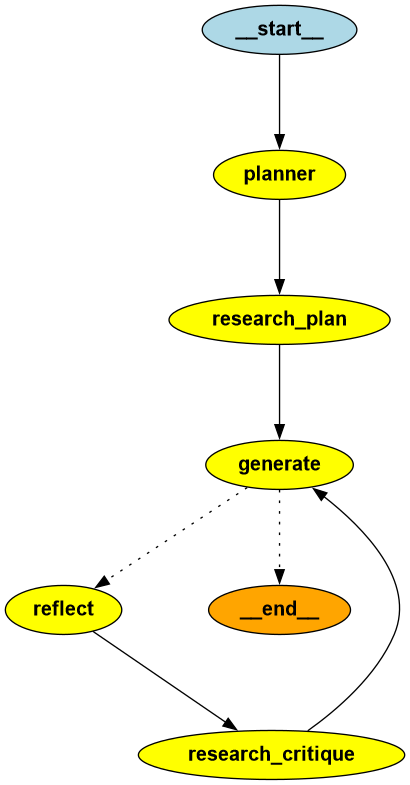

In [24]:
from IPython.display import Image

Image(graph.get_graph().draw_png())

In [27]:
RESEARCH_PLAN_PROMPT = """You are a research assistant.
Generate a short list of search queries that will help answer the user's task.
Return only relevant search queries."""

In [29]:
def research_plan_node(state: AgentState):
    queries = model.with_structured_output(
        Queries, method="function_calling"
    ).invoke([
        SystemMessage(content=RESEARCH_PLAN_PROMPT),
        HumanMessage(content=state["task"])
    ])

    content = state.get("content", [])

    for q in queries.queries:
        response = tavily.search(query=q, max_results=2)
        for r in response["results"]:
            content.append(r["content"])

    return {"content": content}

In [33]:
graph = builder.compile(checkpointer=memory)

In [39]:
builder = StateGraph(AgentState)

builder.add_node("planner", plan_node)
builder.add_node("research_plan", research_plan_node)
builder.add_node("generate", generation_node)
builder.add_node("reflect", reflection_node)
builder.add_node("research_critique", research_critique_node)

builder.set_entry_point("planner")

builder.add_edge("planner", "research_plan")
builder.add_edge("research_plan", "generate")

builder.add_conditional_edges(
    "generate",
    should_continue,
    {
        END: END,
        "reflect": "reflect"
    }
)

builder.add_edge("reflect", "research_critique")
builder.add_edge("research_critique", "generate")

graph = builder.compile(checkpointer=memory)

In [40]:
thread = {"configurable": {"thread_id": "100"}}

for s in graph.stream({
    "task": "what is the difference between langchain and langsmith",
    "max_revisions": 2,
    "revision_number": 1,
    "content": []
}, thread):
    print(s)

{'planner': {'plan': 'I. Introduction\n    A. Brief overview of Langchain and Langsmith\n    B. Thesis statement: Exploring the differences between Langchain and Langsmith\n\nII. Langchain\n    A. Definition and explanation\n    B. Key features and characteristics\n    C. Use cases and applications\n    D. Advantages and disadvantages\n\nIII. Langsmith\n    A. Definition and explanation\n    B. Key features and characteristics\n    C. Use cases and applications\n    D. Advantages and disadvantages\n\nIV. Comparison between Langchain and Langsmith\n    A. Technology stack\n    B. Scalability\n    C. Security\n    D. Interoperability\n    E. Performance\n\nV. Conclusion\n    A. Recap of main differences between Langchain and Langsmith\n    B. Implications for future developments in the field\n    C. Final thoughts on the significance of understanding these differences'}}
{'research_plan': {'content': ['**TL;DR:**\xa0*LangChain and LangSmith play different roles in your LLM dev stack. Lan

In [45]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from uuid import uuid4

# Inputs
topic_box = widgets.Textarea(
    value="Pizza Shop",
    description="Essay Topic:",
    layout=widgets.Layout(width="95%", height="90px")
)

generate_btn = widgets.Button(description="Generate Essay", button_style="warning")
continue_btn = widgets.Button(description="Continue Essay", button_style="info")

last_node_box = widgets.Text(value="", description="last node")
next_node_box = widgets.Text(value="", description="next node")
thread_box = widgets.Text(value="0", description="Thread")
draft_rev_box = widgets.Text(value="0", description="Draft Rev")
count_box = widgets.Text(value="0", description="count")

live_output = widgets.Output()
plan_output = widgets.Output()
research_output = widgets.Output()
draft_output = widgets.Output()
critique_output = widgets.Output()
state_output = widgets.Output()

tabs = widgets.Tab(children=[
    widgets.VBox([
        topic_box,
        widgets.HBox([generate_btn, continue_btn]),
        widgets.HBox([last_node_box, next_node_box, thread_box, draft_rev_box, count_box]),
        widgets.Label("Live Agent Output"),
        live_output
    ]),
    plan_output,
    research_output,
    draft_output,
    critique_output,
    state_output
])

tab_names = ["Agent", "Plan", "Research Content", "Draft", "Critique", "StateSnapshots"]

for i, name in enumerate(tab_names):
    tabs.set_title(i, name)

current_thread = {"configurable": {"thread_id": str(uuid4())}}
current_state = {}

def update_outputs(step):
    global current_state

    node_name = list(step.keys())[0]
    node_data = step[node_name]

    last_node_box.value = node_name
    next_node_box.value = "running..."
    count_box.value = str(int(count_box.value) + 1)

    current_state.update(node_data)

    with live_output:
        print(step)
        print("-" * 80)

    with plan_output:
        clear_output()
        print(current_state.get("plan", "No plan yet."))

    with research_output:
        clear_output()
        content = current_state.get("content", [])
        if content:
            for i, item in enumerate(content, 1):
                print(f"\n--- Research {i} ---\n")
                print(item)
        else:
            print("No research content yet.")

    with draft_output:
        clear_output()
        print(current_state.get("draft", "No draft yet."))

    with critique_output:
        clear_output()
        print(current_state.get("critique", "No critique yet."))

    with state_output:
        clear_output()
        print(current_state)

def generate_essay(b):
    global current_thread, current_state

    current_thread = {"configurable": {"thread_id": str(uuid4())}}
    current_state = {}

    last_node_box.value = ""
    next_node_box.value = ""
    draft_rev_box.value = "1"
    count_box.value = "0"

    with live_output:
        clear_output()

    input_state = {
        "task": topic_box.value,
        "max_revisions": 2,
        "revision_number": 1,
        "content": []
    }

    for step in graph.stream(input_state, current_thread):
        update_outputs(step)

    next_node_box.value = "done"

def continue_essay(b):
    with live_output:
        print("Continue button is ready, but full checkpoint resume will be added next.")

generate_btn.on_click(generate_essay)
continue_btn.on_click(continue_essay)

display(tabs)